# 18 — Expanded LSEG sector-hysteresis scorer robustness

**Objective.** Apply Notebook 17's exact, already-frozen sector-hysteresis
construction to pinned FinBERT and test whether Gemma's stronger gross/cost
profile is scorer-specific on the paired 888,155-headline population.

**Interpretation boundary.** The strategy was selected after observing Gemma
returns, and the same 167-session LSEG window has already been opened. This is
a retrospective scorer falsification—not a model bake-off, an untouched
holdout, or a deployable-alpha claim.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import (  # noqa: E402
    TradeConfig,
    annualized_sharpe,
    summarize_daily_portfolio,
)
from final_experiments.lib.lseg_expanded import (  # noqa: E402
    INFORMATION_BUFFER_MINUTES,
    assert_paired_population,
    build_expanded_aggregation_panel,
    canonical_score_frame,
    load_price_exports,
    load_success_scores,
    map_headlines_to_entry_sessions,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    apply_house_style,
    zero_line,
)
from final_experiments.lib.sector_portfolios import (  # noqa: E402
    SECTOR_BY_SYMBOL,
    SectorPortfolioConfig,
    build_sector_strategy_family,
    circular_block_mean_test,
)

COLLECTION_ROOT = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
FINBERT_SCORES = COLLECTION_ROOT / "headline_scores_finbert4556_cacheonly_20260803.csv"
GEMMA_SCORES = (
    COLLECTION_ROOT
    / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
)
SECTOR33_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
ADD11_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv"
NOTEBOOK17_DAILY = (
    REPO_ROOT
    / "final_experiments/outputs/17_lseg_sector_portfolio_translation/daily_sector_hysteresis.csv"
)
OUTPUT = REPO_ROOT / "final_experiments/outputs/18_lseg_sector_hysteresis_scorer_robustness"
OUTPUT.mkdir(parents=True, exist_ok=True)

CONFIG = SectorPortfolioConfig()
SCORERS = ("finbert", "gemma4_26b")
SCORER_LABELS = {"finbert": "FinBERT", "gemma4_26b": "Gemma 4 26B"}
COSTS_BPS = (0.0, 1.0, 2.0, 4.0, 10.0)
PRIMARY_ESTIMAND = (
    "mean daily gross return difference: Gemma sector_hysteresis minus "
    "FinBERT sector_hysteresis over all 167 policy sessions"
)
apply_house_style()

print("fixed rule: sector_hysteresis; no alternative strategy inspected")
print("signal: strongest_event; orientation +1; horizon h1")
print(f"timing: first XNYS open >= first timestamp + {INFORMATION_BUFFER_MINUTES} minutes")
print("primary estimand:", PRIMARY_ESTIMAND)
print("inference: two-sided 5-session circular-block test; 4,999 replications")
print("status: retrospective paired-scorer robustness; never pooled with FNSPID")

fixed rule: sector_hysteresis; no alternative strategy inspected
signal: strongest_event; orientation +1; horizon h1
timing: first XNYS open >= first timestamp + 15 minutes
primary estimand: mean daily gross return difference: Gemma sector_hysteresis minus FinBERT sector_hysteresis over all 167 policy sessions
inference: two-sided 5-session circular-block test; 4,999 replications
status: retrospective paired-scorer robustness; never pooled with FNSPID


## 1. Frozen comparison and gates

Only one strategy is compared: Notebook 17's sector extremes with equal active-
sector budgets, a six-sector breadth floor, and top-half/bottom-half retention.
Both scorers use the same canonical company associations, timestamps, prices,
h1 return, 10-bps accounting convention, and explicit final liquidation.

The **primary test** is the paired daily gross-return difference, Gemma minus
FinBERT, over the complete 167-session policy grid (flat days remain zero).
A scorer-advantage gate requires a positive 95% block interval, two-sided
p<0.05, and a positive mean difference in both chronological halves. Because
there is exactly one fixed primary comparison, no multiplicity correction is
added. Cost comparisons at 1/2/4/10 bps and common-active-day results are
explicitly secondary diagnostics.

A scorer advantage is not strategy alpha. Each scorer's own strategy is also
checked for a positive gross interval, positive gross means in both halves,
and 10-bps economic viability. No rule, breadth floor, horizon, or retention
band will be changed after seeing this notebook.

## 2. Paired scorer and price contracts

FinBERT probabilities are the pinned exact-hash inheritance. Gemma supplies
canonical 44-company associations and first timestamps because its artifact
was built directly from the expanded population. Headline text is excluded.

In [2]:
finbert_raw, finbert_audit = load_success_scores(FINBERT_SCORES, scorer="finbert")
gemma_raw, gemma_audit = load_success_scores(GEMMA_SCORES, scorer="gemma4_26b")
paired = assert_paired_population(finbert_raw, gemma_raw)
prices = load_price_exports(SECTOR33_PRICES, ADD11_PRICES)

canonical_scores = {
    "finbert": canonical_score_frame(paired, scorer="finbert"),
    "gemma4_26b": canonical_score_frame(paired, scorer="gemma"),
}
mapped_events = {
    scorer: map_headlines_to_entry_sessions(scores, prices)
    for scorer, scores in canonical_scores.items()
}
panels = {
    scorer: build_expanded_aggregation_panel(events, prices)
    for scorer, events in mapped_events.items()
}

input_audit = pd.DataFrame(
    [
        {
            **{key: value for key, value in audit.items() if key != "status_counts"},
            **{f"status_{key}": value for key, value in audit["status_counts"].items()},
        }
        for audit in (finbert_audit, gemma_audit)
    ]
)
panel_audit = pd.DataFrame(
    [
        {
            "scorer": scorer,
            "headline_company_associations": len(mapped_events[scorer]),
            "firm_open_rows": len(panel),
            "priced_firm_open_rows": int(panel["raw_open_h1"].notna().sum()),
            "sessions": int(panel["session_date"].nunique()),
            "companies": int(panel["symbol"].nunique()),
        }
        for scorer, panel in panels.items()
    ]
)
input_audit.to_csv(OUTPUT / "input_score_audit.csv", index=False)
panel_audit.to_csv(OUTPUT / "panel_audit.csv", index=False)
display(input_audit)
display(panel_audit)

,scorer,rows_including_historical_attempts,unique_successes,duplicate_successes,invalid_success_probabilities,reported_cost_usd_sum,output_sha256,status_success,status_api_error,status_invalid_output,status_malformed_response
0,finbert,888155,888155,0,0,0.000000,737287a167dea8f3a7f03c53f020d6606a4f0554dc105b...,888155,NaN,NaN,NaN
1,gemma4_26b,889103,888155,0,0,33.615345,afb2d9c3029c4fba4fce3600218233a02d14051788f873...,888155,919.0,27.0,2.0


,scorer,headline_company_associations,firm_open_rows,priced_firm_open_rows,sessions,companies
0,finbert,929691,7348,7348,167,44
1,gemma4_26b,929691,7348,7348,167,44


In [3]:
panel_pair = panels["gemma4_26b"][[
    "symbol",
    "session_date",
    "strongest_event",
    "raw_open_h1",
]].merge(
    panels["finbert"][["symbol", "session_date", "strongest_event", "raw_open_h1"]],
    on=["symbol", "session_date"],
    suffixes=("_gemma", "_finbert"),
    validate="one_to_one",
)
assert len(panel_pair) == len(panels["gemma4_26b"]) == len(panels["finbert"])
return_difference = (
    panel_pair["raw_open_h1_gemma"] - panel_pair["raw_open_h1_finbert"]
).abs()
assert return_difference.fillna(0.0).max() < 1e-15

valid_signal = panel_pair.dropna(
    subset=["strongest_event_gemma", "strongest_event_finbert"]
)
daily_signal_ic = (
    valid_signal
    .groupby("session_date")
    .apply(
        lambda day: day["strongest_event_gemma"].corr(
            day["strongest_event_finbert"], method="spearman"
        ),
        include_groups=False,
    )
    .dropna()
)
signal_agreement = {
    "paired_firm_open_rows": int(len(panel_pair)),
    "pairwise_nonmissing_signal_rows": int(len(valid_signal)),
    "pairwise_nonmissing_signal_share": float(len(valid_signal) / len(panel_pair)),
    "overall_spearman": float(
        panel_pair["strongest_event_gemma"].corr(
            panel_pair["strongest_event_finbert"], method="spearman"
        )
    ),
    "mean_daily_cross_sectional_spearman": float(daily_signal_ic.mean()),
    "median_daily_cross_sectional_spearman": float(daily_signal_ic.median()),
    "same_sign_share_pairwise_nonmissing": float(
        np.sign(valid_signal["strongest_event_gemma"])
        .eq(np.sign(valid_signal["strongest_event_finbert"]))
        .mean()
    ),
}
pd.DataFrame([signal_agreement]).to_csv(OUTPUT / "signal_agreement.csv", index=False)
display(pd.DataFrame([signal_agreement]))

,paired_firm_open_rows,pairwise_nonmissing_signal_rows,pairwise_nonmissing_signal_share,overall_spearman,mean_daily_cross_sectional_spearman,median_daily_cross_sectional_spearman,same_sign_share_pairwise_nonmissing
0,7348,3841,0.522727,0.246168,0.212132,0.206417,0.375944


### Post-result score-resolution mechanism audit

The first execution showed sharply different activity (FinBERT traded every
session; Gemma traded 57). This return-blind follow-up was added after that
result and is therefore labelled diagnostic. `strongest_event` returns missing
when the maximum-absolute-score stories tie across opposing directions. That
behaviour is rare for continuous FinBERT margins but common when Gemma emits a
small set of repeated probability margins. The table measures the resulting
abstention and sector-breadth gate directly; it does not test another signal.

In [4]:
resolution_rows = []
for scorer in SCORERS:
    priced = panels[scorer].loc[panels[scorer]["raw_open_h1"].notna()].copy()
    assert priced["mean_continuous"].notna().all()
    priced["sector"] = priced["symbol"].map(SECTOR_BY_SYMBOL)
    signal = priced["strongest_event"]
    nonmissing = signal.dropna()
    sector_day = (
        priced.dropna(subset=["strongest_event"])
        .groupby(["session_date", "sector"])
        .agg(
            firms=("symbol", "size"),
            unique_signals=("strongest_event", "nunique"),
        )
        .reset_index()
    )
    sector_day["eligible"] = sector_day["firms"].ge(2) & sector_day[
        "unique_signals"
    ].ge(2)
    eligible_by_session = (
        sector_day.groupby("session_date")["eligible"]
        .sum()
        .reindex(sorted(priced["session_date"].unique()), fill_value=0)
    )
    resolution_rows.append(
        {
            "scorer": scorer,
            "priced_firm_open_rows": len(priced),
            "strongest_event_nonmissing_rows": int(signal.notna().sum()),
            "strongest_event_nonmissing_share": float(signal.notna().mean()),
            "conflicting_top_abs_tie_rows": int(signal.isna().sum()),
            "conflicting_top_abs_tie_share": float(signal.isna().mean()),
            "unique_nonmissing_signal_values": int(nonmissing.nunique()),
            "modal_nonmissing_signal_share": float(
                nonmissing.value_counts().iloc[0] / len(nonmissing)
            ),
            "eligible_sector_days": int(sector_day["eligible"].sum()),
            "mean_eligible_sectors_per_session": float(eligible_by_session.mean()),
            "sessions_meeting_six_sector_floor": int(
                eligible_by_session.ge(CONFIG.min_active_sectors).sum()
            ),
        }
    )
resolution = pd.DataFrame(resolution_rows)
resolution.to_csv(OUTPUT / "score_resolution_and_abstention.csv", index=False)
display(resolution.style.format(precision=4))

,scorer,priced_firm_open_rows,strongest_event_nonmissing_rows,strongest_event_nonmissing_share,conflicting_top_abs_tie_rows,conflicting_top_abs_tie_share,unique_nonmissing_signal_values,modal_nonmissing_signal_share,eligible_sector_days,mean_eligible_sectors_per_session,sessions_meeting_six_sector_floor
0,finbert,7348,7348,1.0000,0,0.0000,7315,0.0005,1837,11.0000,167
1,gemma4_26b,7348,3841,0.5227,3507,0.4773,16,0.5535,814,4.8743,57


findfont: Failed to find font weight medium, now using 400.


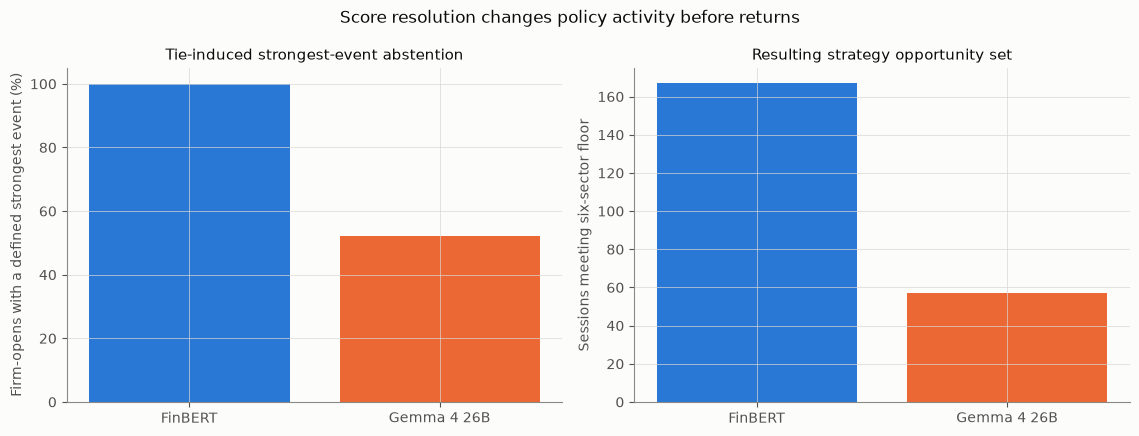

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
x = np.arange(len(SCORERS))
bar_colours = [CATEGORICAL[0], CATEGORICAL[1]]
axes[0].bar(
    x,
    100 * resolution.set_index("scorer").loc[list(SCORERS), "strongest_event_nonmissing_share"],
    color=bar_colours,
)
axes[1].bar(
    x,
    resolution.set_index("scorer").loc[list(SCORERS), "sessions_meeting_six_sector_floor"],
    color=bar_colours,
)
for ax in axes:
    ax.set_xticks(x, [SCORER_LABELS[scorer] for scorer in SCORERS])
axes[0].set(ylabel="Firm-opens with a defined strongest event (%)", ylim=(0, 105))
axes[1].set(ylabel="Sessions meeting six-sector floor", ylim=(0, 175))
axes[0].set_title("Tie-induced strongest-event abstention")
axes[1].set_title("Resulting strategy opportunity set")
fig.suptitle("Score resolution changes policy activity before returns")
fig.tight_layout()
fig.savefig(OUTPUT / "score_resolution_activity.png", dpi=160, bbox_inches="tight")
plt.show()

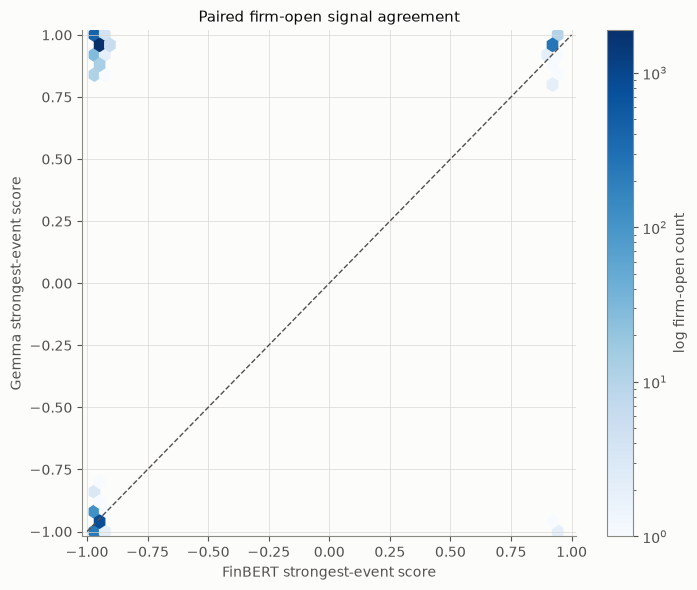

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 6.0))
hexbin = ax.hexbin(
    valid_signal["strongest_event_finbert"],
    valid_signal["strongest_event_gemma"],
    gridsize=45,
    mincnt=1,
    bins="log",
    cmap="Blues",
)
ax.plot([-1, 1], [-1, 1], color=INK["reference"], lw=1, linestyle="--")
ax.set(
    xlabel="FinBERT strongest-event score",
    ylabel="Gemma strongest-event score",
    title="Paired firm-open signal agreement",
    xlim=(-1.02, 1.02),
    ylim=(-1.02, 1.02),
)
fig.colorbar(hexbin, ax=ax, label="log firm-open count")
fig.tight_layout()
fig.savefig(OUTPUT / "paired_signal_hexbin.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Exact sector-hysteresis portfolios

The shared helper constructs all four fixed translations internally, but this
notebook extracts and evaluates only `sector_hysteresis`. The other strategies
are neither tabulated nor used for selection. Gemma must reproduce Notebook
17's ignored daily artifact to floating-point tolerance before comparison.

In [7]:
daily_outputs = {
    scorer: build_sector_strategy_family(panel, config=CONFIG)["sector_hysteresis"]
    for scorer, panel in panels.items()
}
for scorer, daily in daily_outputs.items():
    daily.to_csv(OUTPUT / f"daily_{scorer}_sector_hysteresis.csv", index=False)

assert daily_outputs["finbert"]["session_date"].equals(
    daily_outputs["gemma4_26b"]["session_date"]
)
assert len(daily_outputs["finbert"]) == len(daily_outputs["gemma4_26b"]) == 167

reference_check = {
    "notebook17_daily_available": NOTEBOOK17_DAILY.is_file(),
    "rows_compared": 0,
    "max_abs_gross_return_difference": None,
    "max_abs_turnover_difference": None,
    "max_abs_net_return_difference": None,
}
if NOTEBOOK17_DAILY.is_file():
    prior = pd.read_csv(NOTEBOOK17_DAILY, parse_dates=["session_date"])
    current = daily_outputs["gemma4_26b"]
    reproduced = prior.merge(
        current,
        on="session_date",
        suffixes=("_prior", "_current"),
        validate="one_to_one",
    )
    reference_check.update(
        {
            "rows_compared": len(reproduced),
            "max_abs_gross_return_difference": float(
                (
                    reproduced["gross_return_prior"]
                    - reproduced["gross_return_current"]
                ).abs().max()
            ),
            "max_abs_turnover_difference": float(
                (reproduced["turnover_prior"] - reproduced["turnover_current"])
                .abs()
                .max()
            ),
            "max_abs_net_return_difference": float(
                (reproduced["net_return_prior"] - reproduced["net_return_current"])
                .abs()
                .max()
            ),
        }
    )
    assert len(reproduced) == len(prior) == len(current)
    assert reference_check["max_abs_gross_return_difference"] < 1e-14
    assert reference_check["max_abs_turnover_difference"] < 1e-14
    assert reference_check["max_abs_net_return_difference"] < 1e-14
pd.DataFrame([reference_check]).to_csv(OUTPUT / "gemma_reference_reproduction.csv", index=False)
display(pd.DataFrame([reference_check]))

,notebook17_daily_available,rows_compared,max_abs_gross_return_difference,max_abs_turnover_difference,max_abs_net_return_difference
0,True,167,9.714451e-17,0.0,9.757820e-17


## 4. Scorer-level results and the primary paired test

In [8]:
summary_config = TradeConfig(
    outcome=CONFIG.outcome,
    position_mode="cs_rank",
    threshold=0.0,
    min_names=CONFIG.min_global_names,
    cost_bps_per_side=CONFIG.cost_bps_per_side,
    annualization_periods=CONFIG.annualization_periods,
    bootstrap_block_length=CONFIG.bootstrap_block_length,
    bootstrap_replications=CONFIG.bootstrap_replications,
    random_seed=CONFIG.random_seed,
)

scorer_rows = []
for scorer in SCORERS:
    daily = daily_outputs[scorer]
    summary = summarize_daily_portfolio(daily, config=summary_config)
    gross_test = circular_block_mean_test(
        daily["gross_return"].to_numpy(dtype=float),
        block_length=CONFIG.bootstrap_block_length,
        replications=CONFIG.bootstrap_replications,
        seed=CONFIG.random_seed,
    )
    midpoint = len(daily) // 2
    first = daily.iloc[:midpoint]
    second = daily.iloc[midpoint:]
    active = daily["gross_exposure"].gt(0)
    scorer_rows.append(
        {
            "scorer": scorer,
            **summary,
            "gross_mean_ci_low": gross_test["ci_low"],
            "gross_mean_ci_high": gross_test["ci_high"],
            "gross_mean_p_two_sided": gross_test["p_two_sided"],
            "gross_total_return": float((1.0 + daily["gross_return"]).prod() - 1.0),
            "net_total_return": float((1.0 + daily["net_return"]).prod() - 1.0),
            "active_sessions": int(active.sum()),
            "active_session_share": float(active.mean()),
            "maximum_abs_weight": float(daily["max_abs_weight"].max()),
            "first_half_mean_gross": float(first["gross_return"].mean()),
            "second_half_mean_gross": float(second["gross_return"].mean()),
            "first_half_sharpe_gross": annualized_sharpe(first["gross_return"]),
            "second_half_sharpe_gross": annualized_sharpe(second["gross_return"]),
        }
    )
scorer_results = pd.DataFrame(scorer_rows)
scorer_results["positive_both_halves"] = scorer_results[
    "first_half_mean_gross"
].gt(0) & scorer_results["second_half_mean_gross"].gt(0)
scorer_results["economically_viable_10bps"] = (
    scorer_results["sharpe_net"].gt(0)
    & scorer_results["breakeven_bps_per_side"].ge(CONFIG.cost_bps_per_side)
    & scorer_results["bootstrap_net_ci_low"].gt(0)
)
scorer_results["retrospective_alpha_evidence_gate"] = (
    scorer_results["gross_mean_ci_low"].gt(0)
    & scorer_results["positive_both_halves"]
    & scorer_results["economically_viable_10bps"]
)
scorer_results.to_csv(OUTPUT / "scorer_strategy_results.csv", index=False)

show = [
    "scorer",
    "active_sessions",
    "mean_gross",
    "gross_mean_ci_low",
    "gross_mean_ci_high",
    "gross_mean_p_two_sided",
    "sharpe_gross",
    "mean_turnover",
    "breakeven_bps_per_side",
    "sharpe_net",
    "bootstrap_net_ci_low",
    "bootstrap_net_ci_high",
    "positive_both_halves",
    "retrospective_alpha_evidence_gate",
]
display(scorer_results[show].style.format(precision=5))

,scorer,active_sessions,mean_gross,gross_mean_ci_low,gross_mean_ci_high,gross_mean_p_two_sided,sharpe_gross,mean_turnover,breakeven_bps_per_side,sharpe_net,bootstrap_net_ci_low,bootstrap_net_ci_high,positive_both_halves,retrospective_alpha_evidence_gate
0,finbert,167,0.00012,-0.00037,0.00059,0.61140,0.56179,0.38514,1.60346,-2.92381,-0.00116,-0.00017,False,False
1,gemma4_26b,57,0.00023,-0.00011,0.00061,0.22640,1.39331,0.28002,4.05251,-2.01468,-0.00068,0.00004,True,False


In [9]:
paired_daily = daily_outputs["gemma4_26b"][[
    "session_date",
    "gross_return",
    "turnover",
    "gross_exposure",
]].merge(
    daily_outputs["finbert"][[
        "session_date",
        "gross_return",
        "turnover",
        "gross_exposure",
    ]],
    on="session_date",
    suffixes=("_gemma", "_finbert"),
    validate="one_to_one",
)
paired_daily["gross_difference"] = (
    paired_daily["gross_return_gemma"] - paired_daily["gross_return_finbert"]
)
primary_test = circular_block_mean_test(
    paired_daily["gross_difference"].to_numpy(dtype=float),
    block_length=CONFIG.bootstrap_block_length,
    replications=CONFIG.bootstrap_replications,
    seed=CONFIG.random_seed,
)
midpoint = len(paired_daily) // 2
first_difference = float(paired_daily.iloc[:midpoint]["gross_difference"].mean())
second_difference = float(paired_daily.iloc[midpoint:]["gross_difference"].mean())
scorer_advantage_gate = bool(
    primary_test["ci_low"] > 0
    and primary_test["p_two_sided"] < 0.05
    and first_difference > 0
    and second_difference > 0
)

activity = {
    "sessions": len(paired_daily),
    "finbert_active_sessions": int(paired_daily["gross_exposure_finbert"].gt(0).sum()),
    "gemma_active_sessions": int(paired_daily["gross_exposure_gemma"].gt(0).sum()),
    "both_active_sessions": int(
        (
            paired_daily["gross_exposure_finbert"].gt(0)
            & paired_daily["gross_exposure_gemma"].gt(0)
        ).sum()
    ),
    "finbert_only_active_sessions": int(
        (
            paired_daily["gross_exposure_finbert"].gt(0)
            & paired_daily["gross_exposure_gemma"].eq(0)
        ).sum()
    ),
    "gemma_only_active_sessions": int(
        (
            paired_daily["gross_exposure_gemma"].gt(0)
            & paired_daily["gross_exposure_finbert"].eq(0)
        ).sum()
    ),
    "daily_gross_return_correlation": float(
        paired_daily["gross_return_gemma"].corr(paired_daily["gross_return_finbert"])
    ),
}
primary_result = {
    "estimand": PRIMARY_ESTIMAND,
    "mean_difference": primary_test["mean"],
    "bootstrap_se": primary_test["se"],
    "ci_low": primary_test["ci_low"],
    "ci_high": primary_test["ci_high"],
    "p_two_sided": primary_test["p_two_sided"],
    "first_half_mean_difference": first_difference,
    "second_half_mean_difference": second_difference,
    "scorer_advantage_gate": scorer_advantage_gate,
}
pd.DataFrame([activity]).to_csv(OUTPUT / "activity_overlap.csv", index=False)
pd.DataFrame([primary_result]).to_csv(OUTPUT / "primary_paired_result.csv", index=False)
display(pd.DataFrame([activity]))
display(pd.DataFrame([primary_result]).T.rename(columns={0: "value"}))

,sessions,finbert_active_sessions,gemma_active_sessions,both_active_sessions,finbert_only_active_sessions,gemma_only_active_sessions,daily_gross_return_correlation
0,167,167,57,57,110,0,0.071714


,value
estimand,mean daily gross return difference: Gemma sect...
mean_difference,0.000103
bootstrap_se,0.00031
ci_low,-0.000486
ci_high,0.000715
p_two_sided,0.731
first_half_mean_difference,0.000243
second_half_mean_difference,-0.000035
scorer_advantage_gate,False


## 5. Fixed-weight cost sensitivity

These rows reprice each scorer's unchanged daily weights. The gross difference
is the sole primary test; cost-specific paired tests are secondary and are not
used to select a preferred cost or strategy.

In [10]:
cost_rows = []
paired_cost_rows = []
for cost_bps in COSTS_BPS:
    repriced = {}
    for scorer in SCORERS:
        daily = daily_outputs[scorer]
        net = (
            daily["gross_return"]
            - 2.0 * daily["turnover"] * cost_bps / 10_000.0
        )
        repriced[scorer] = net.to_numpy(dtype=float)
        cost_rows.append(
            {
                "scorer": scorer,
                "cost_bps_per_side": cost_bps,
                "mean_net": float(net.mean()),
                "sharpe_net": annualized_sharpe(net),
                "total_net_return": float((1.0 + net).prod() - 1.0),
            }
        )
    difference = repriced["gemma4_26b"] - repriced["finbert"]
    test = circular_block_mean_test(
        difference,
        block_length=CONFIG.bootstrap_block_length,
        replications=CONFIG.bootstrap_replications,
        seed=CONFIG.random_seed,
    )
    paired_cost_rows.append(
        {
            "cost_bps_per_side": cost_bps,
            "gemma_minus_finbert_mean": test["mean"],
            "ci_low": test["ci_low"],
            "ci_high": test["ci_high"],
            "p_two_sided_secondary": test["p_two_sided"],
        }
    )
cost_curve = pd.DataFrame(cost_rows)
paired_cost = pd.DataFrame(paired_cost_rows)
cost_curve.to_csv(OUTPUT / "scorer_cost_curve.csv", index=False)
paired_cost.to_csv(OUTPUT / "paired_cost_differences_secondary.csv", index=False)
display(cost_curve.style.format(precision=5))
display(paired_cost.style.format(precision=5))

,scorer,cost_bps_per_side,mean_net,sharpe_net,total_net_return
0,finbert,0.00000,0.00012,0.56179,0.01981
1,gemma4_26b,0.00000,0.00023,1.39331,0.03805
2,finbert,1.00000,0.00005,0.21135,0.00677
3,gemma4_26b,1.00000,0.00017,1.05015,0.02839
4,finbert,2.00000,-0.00003,-0.13882,-0.00610
5,gemma4_26b,2.00000,0.00011,0.70623,0.01882
6,finbert,4.00000,-0.00018,-0.83816,-0.03134
7,gemma4_26b,4.00000,0.00000,0.01805,-0.00006
8,finbert,10.00000,-0.00065,-2.92381,-0.10333
9,gemma4_26b,10.00000,-0.00033,-2.01468,-0.05466


,cost_bps_per_side,gemma_minus_finbert_mean,ci_low,ci_high,p_two_sided_secondary
0,0.00000,0.00010,-0.00049,0.00072,0.73100
1,1.00000,0.00012,-0.00047,0.00073,0.68280
2,2.00000,0.00015,-0.00045,0.00076,0.63740
3,4.00000,0.00019,-0.00041,0.00080,0.54900
4,10.00000,0.00031,-0.00030,0.00093,0.32620


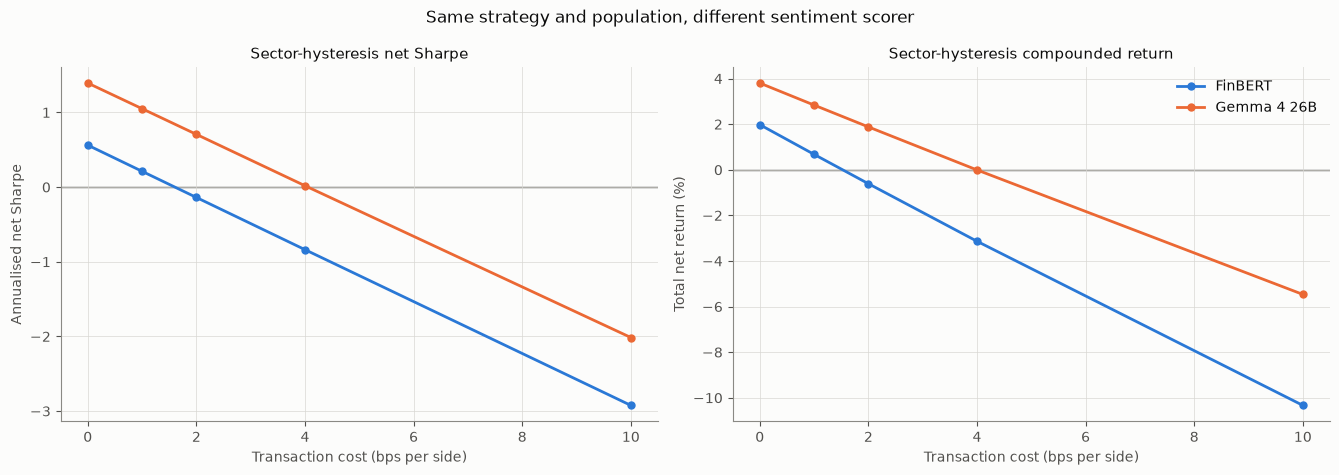

In [11]:
colours = {"finbert": CATEGORICAL[0], "gemma4_26b": CATEGORICAL[1]}
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for scorer in SCORERS:
    curve = cost_curve.loc[cost_curve["scorer"].eq(scorer)]
    axes[0].plot(
        curve["cost_bps_per_side"],
        curve["sharpe_net"],
        marker="o",
        color=colours[scorer],
        label=SCORER_LABELS[scorer],
    )
    axes[1].plot(
        curve["cost_bps_per_side"],
        100 * curve["total_net_return"],
        marker="o",
        color=colours[scorer],
        label=SCORER_LABELS[scorer],
    )
zero_line(axes[0])
zero_line(axes[1])
axes[0].set(xlabel="Transaction cost (bps per side)", ylabel="Annualised net Sharpe")
axes[1].set(xlabel="Transaction cost (bps per side)", ylabel="Total net return (%)")
axes[0].set_title("Sector-hysteresis net Sharpe")
axes[1].set_title("Sector-hysteresis compounded return")
axes[1].legend()
fig.suptitle("Same strategy and population, different sentiment scorer")
fig.tight_layout()
fig.savefig(OUTPUT / "scorer_cost_curve.png", dpi=160, bbox_inches="tight")
plt.show()

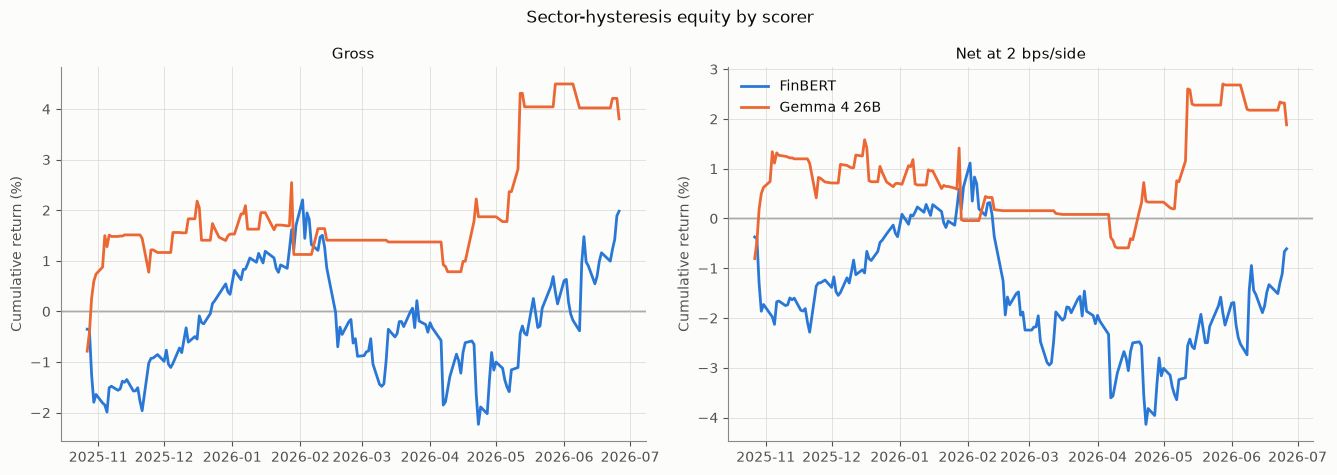

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True)
for scorer in SCORERS:
    daily = daily_outputs[scorer]
    gross_equity = (1.0 + daily["gross_return"]).cumprod() - 1.0
    net_two = daily["gross_return"] - 2.0 * daily["turnover"] * 2.0 / 10_000.0
    net_two_equity = (1.0 + net_two).cumprod() - 1.0
    axes[0].plot(
        daily["session_date"],
        100 * gross_equity,
        color=colours[scorer],
        label=SCORER_LABELS[scorer],
    )
    axes[1].plot(
        daily["session_date"],
        100 * net_two_equity,
        color=colours[scorer],
        label=SCORER_LABELS[scorer],
    )
zero_line(axes[0])
zero_line(axes[1])
axes[0].set(title="Gross", ylabel="Cumulative return (%)")
axes[1].set(title="Net at 2 bps/side", ylabel="Cumulative return (%)")
axes[1].legend()
fig.suptitle("Sector-hysteresis equity by scorer")
fig.tight_layout()
fig.savefig(OUTPUT / "scorer_equity.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Decision

The scorer-advantage and own-alpha gates are separate. Gemma can outperform
FinBERT without either being a viable strategy. Any future confirmation must
keep this exact Gemma sector-hysteresis rule and use a separately frozen time
window; this notebook closes the current window to further strategy tuning.

In [13]:
gemma_result = scorer_results.set_index("scorer").loc["gemma4_26b"]
finbert_result = scorer_results.set_index("scorer").loc["finbert"]
decision = {
    "scorer_advantage_gate": scorer_advantage_gate,
    "gemma_retrospective_alpha_evidence_gate": bool(
        gemma_result["retrospective_alpha_evidence_gate"]
    ),
    "finbert_retrospective_alpha_evidence_gate": bool(
        finbert_result["retrospective_alpha_evidence_gate"]
    ),
    "gemma_gross_sharpe": float(gemma_result["sharpe_gross"]),
    "finbert_gross_sharpe": float(finbert_result["sharpe_gross"]),
    "gemma_break_even_bps_per_side": float(gemma_result["breakeven_bps_per_side"]),
    "finbert_break_even_bps_per_side": float(finbert_result["breakeven_bps_per_side"]),
    "primary_mean_difference_bps_per_day": 10_000.0 * float(primary_test["mean"]),
    "primary_p_two_sided": float(primary_test["p_two_sided"]),
    "gemma_conflicting_top_abs_tie_share": float(
        resolution.set_index("scorer").loc["gemma4_26b", "conflicting_top_abs_tie_share"]
    ),
    "comparison_includes_resolution_induced_abstention": True,
}
display(pd.DataFrame([decision]))
if not scorer_advantage_gate:
    print("RESULT: no robust Gemma-over-FinBERT advantage under the frozen strategy.")
elif not bool(gemma_result["retrospective_alpha_evidence_gate"]):
    print("RESULT: Gemma beats FinBERT, but the Gemma strategy still fails its own alpha gate.")
else:
    print("RESULT: retrospective gates pass; require untouched-window confirmation before any claim.")

,scorer_advantage_gate,gemma_retrospective_alpha_evidence_gate,finbert_retrospective_alpha_evidence_gate,gemma_gross_sharpe,finbert_gross_sharpe,gemma_break_even_bps_per_side,finbert_break_even_bps_per_side,primary_mean_difference_bps_per_day,primary_p_two_sided,gemma_conflicting_top_abs_tie_share,comparison_includes_resolution_induced_abstention
0,False,False,False,1.393313,0.561789,4.052505,1.60346,1.034463,0.731,0.477273,True


RESULT: no robust Gemma-over-FinBERT advantage under the frozen strategy.


In [14]:
manifest = {
    "status": "RETROSPECTIVE_PAIRED_SCORER_ROBUSTNESS",
    "population": {
        "unique_normalized_headlines": 888_155,
        "companies": 44,
        "priced_firm_opens_per_scorer": int(
            panels["gemma4_26b"]["raw_open_h1"].notna().sum()
        ),
        "policy_sessions": len(paired_daily),
    },
    "scorers": {
        "finbert": "ProsusAI/finbert@4556d13015211d73dccd3fdd39d39232506f3e43",
        "gemma4_26b": "google/gemma-4-26b-a4b-it via DeepInfra FP8",
    },
    "strategy": {
        "name": "sector_hysteresis",
        "signal": "strongest_event",
        "orientation": 1.0,
        "horizon_sessions": 1,
        "minimum_active_sectors": CONFIG.min_active_sectors,
        "retention": "retain long in current top half; retain short in current bottom half",
        "cost_bps_per_side": CONFIG.cost_bps_per_side,
        "final_liquidation": True,
    },
    "inference": {
        "primary_estimand": PRIMARY_ESTIMAND,
        "block_length_sessions": CONFIG.bootstrap_block_length,
        "replications": CONFIG.bootstrap_replications,
        "seed": CONFIG.random_seed,
        "multiplicity": "one fixed primary paired test; no correction",
    },
    "signal_agreement": signal_agreement,
    "score_resolution_and_abstention": json.loads(
        resolution.to_json(orient="records")
    ),
    "activity_overlap": activity,
    "primary_result": primary_result,
    "decision": decision,
    "gemma_reference_reproduction": reference_check,
    "limitations": [
        "strategy chosen after Gemma returns were observed in the same window",
        "same already-opened eight-month raw-return window as Notebooks 13 and 17",
        "FinBERT metadata are canonicalised to the current Gemma-built 44-company population",
        "strongest-event tie handling interacts with scorer resolution: Gemma "
        "abstains on conflicting maximum-absolute-score ties while FinBERT almost never ties",
        "fixed current sector labels are control strata, not point-in-time sector history",
        "headline sentiment has no completed human-accuracy audit on this licensed corpus",
        "cost-specific paired tests are secondary diagnostics, not selection tests",
        "no scorer or strategy result is promoted without an untouched time window",
    ],
}
(OUTPUT / "manifest.json").write_text(
    json.dumps(manifest, indent=2) + "\n", encoding="utf-8"
)
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_PAIRED_SCORER_ROBUSTNESS",
  "population": {
    "unique_normalized_headlines": 888155,
    "companies": 44,
    "priced_firm_opens_per_scorer": 7348,
    "policy_sessions": 167
  },
  "scorers": {
    "finbert": "ProsusAI/finbert@4556d13015211d73dccd3fdd39d39232506f3e43",
    "gemma4_26b": "google/gemma-4-26b-a4b-it via DeepInfra FP8"
  },
  "strategy": {
    "name": "sector_hysteresis",
    "signal": "strongest_event",
    "orientation": 1.0,
    "horizon_sessions": 1,
    "minimum_active_sectors": 6,
    "retention": "retain long in current top half; retain short in current bottom half",
    "cost_bps_per_side": 10.0,
    "final_liquidation": true
  },
  "inference": {
    "primary_estimand": "mean daily gross return difference: Gemma sector_hysteresis minus FinBERT sector_hysteresis over all 167 policy sessions",
    "block_length_sessions": 5,
    "replications": 4999,
    "seed": 20260805,
    "multiplicity": "one fixed primary paired test; no correct

## Next step

Preserve this paired result. Do not try another scorer-specific portfolio rule
on the current 167 sessions. The only defensible alpha follow-up is an exact
replay of the frozen Gemma sector-hysteresis policy on a separately collected
earlier or later LSEG window; otherwise use the result as evidence about model
sensitivity, turnover, activity, and transaction-cost limits.